# Q1. How should ClinVar missense variants be split for reliable evaluation on previously unseen genes?

Apply Q0’s quality filters and the exact ClinVar missense annotation to obtain **65,270 eligible missense SNVs**, then build a reproducible **5,000-variant pilot**. [Dependencies](../requirements.txt) · [Implementation](src/q1.py) · CPU only.

This pilot uses the pinned **5 September 2026** ClinVar snapshot. Q0’s current **6 July 2026** download is a separate input.

In [1]:
from src import q1
q1.settings()

Q0 cohort → exact MC missense filter → 5,000-variant pilot → frozen training / validation groups
1,024-base windows · seed 42 · approximately 70% / 30% · CPU only
data/clinvar-train-pilot.vcf = training; data/clinvar-test-pilot.vcf = validation (no separate test stage).


## Eligibility filters: Q0 plus missense

Q1 rebuilds the eligible cohort from the pinned **2026-09-05 GRCh38 ClinVar VCF** using [Q0’s filtering function](src/q0.py), followed by the missense filter in [Q1](src/q1.py). The filters below are applied in order; counts describe the recorded run.

| Step | Records retained |
| --- | ---: |
| All input records | 4,469,028 |
| Exclude duplicate variant keys with inconsistent annotations | 4,469,028 |
| Keep chromosomes **1–22, X and Y** | 4,465,847 |
| Keep single-base **A/C/G/T substitutions**, with REF different from ALT | 4,157,786 |
| Exclude germline classification conflicts | 3,998,278 |
| Keep accepted benign or pathogenic classifications | 1,486,095 |
| Require **at least two review stars** | 346,039 |
| Require **at least one usable gene ID** | 346,038 |
| Collapse consistent duplicate variant keys | 346,038 |
| Require exact `MC` consequence **`SO:0001583` (missense)** | **65,270** |

Accepted `CLNSIG` values are exactly `Benign`, `Likely_benign`, `Benign/Likely_benign`, `Pathogenic`, `Likely_pathogenic` and `Pathogenic/Likely_pathogenic`. These map to two classes: benign and pathogenic. Uncertain, missing and other classifications are excluded. Conflict evidence means a populated `CLNSIGCONF`, conflict text in `CLNSIG`, or conflict text in `CLNREVSTAT` other than `no_conflicts`.

The review threshold accepts `criteria_provided,_multiple_submitters,_no_conflicts` (2 stars), `reviewed_by_expert_panel` (3) and `practice_guideline` (4). A usable gene is a `GENEINFO` entry with a nonempty symbol and a positive numeric NCBI Gene ID; all usable IDs are retained. Duplicate keys are defined by chromosome, position, REF and ALT. Keys with inconsistent annotations are excluded entirely; consistent duplicates are collapsed while preserving contributing source IDs. Neither duplicate step removed records in this run.

The missense filter matches the exact SO identifier among comma-separated `MC` terms. Missing annotations and records without `SO:0001583` are excluded. A record can also have other consequences on other transcripts; all its gene associations are retained. `MC` is used only for eligibility and audit, and is excluded from DNA predictor inputs.

These rules define eligibility using clinical labels and review annotations. Sampling and split assignment below use no labels. See the [recorded filter counts](results/q1/filter_counts.csv).

## Group the full cohort

Build groups across **all 346,038 Q0-eligible SNVs**, retaining nonmissense variants as relationship bridges. Join variants sharing genes, loci, source IDs or overlapping **1,024-base windows**. Connections are transitive, including through variants outside the missense pilot.

Keep the earlier full-cohort split assignments. A pinned fingerprint of every `(variant_key, split)` pair stops execution if any assignment changes. Grouping keeps related variants together; only missense candidates enter sampling.

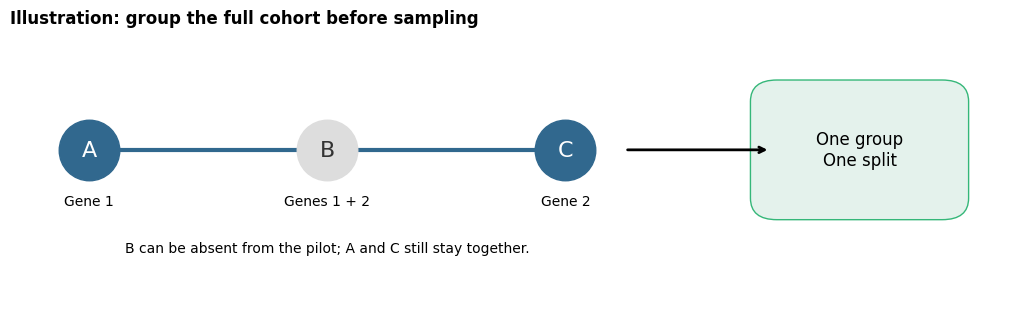

In [2]:
q1.show_grouping()

## Sample and freeze

Select **5,000 of the 65,270 eligible missense variants** by taking the lowest `SHA256(42:sample:variant_key)` hashes. This deterministic sample uses seed **42**, without label stratification or class balancing. The 5,000-variant cap keeps later Evo2 experiments manageable.

For each sampled variant, verify REF against the pinned GRCh38 FASTA and extract its **1,024-base reference and alternate windows**. Exclude a variant if its window extends beyond a chromosome boundary (`truncated_window`) or contains any base outside A/C/G/T (`non_ACGT_window`). Exclusions are made **without replacement**. A REF mismatch stops execution. The recorded run has **zero sequence exclusions**, so all **5,000 variants** remain; see the [sequence exclusion log](results/q1/sequence_exclusions.csv).

Merge groups with identical reference or alternate contexts, including reverse complements. Use the existing whole-group assignments, originally generated with a **70% training / 30% validation** hash and seed **42**. Assignment uses no labels; incompatible new context relationships stop execution instead of moving existing variants.

In [3]:
q1.run_checks()
pilot, sequences = q1.prepare()

21 split and sequence integrity tests passed.


5,000 sampled variants retained; 6 leakage check groups passed.


## What each split is for

**Training** fits scaling and classifiers. **Validation** chooses settings and compares models. There is no separate test stage. Genes are disjoint; each variant’s reference and alternate windows stay together. Different group sizes make the percentages approximate.

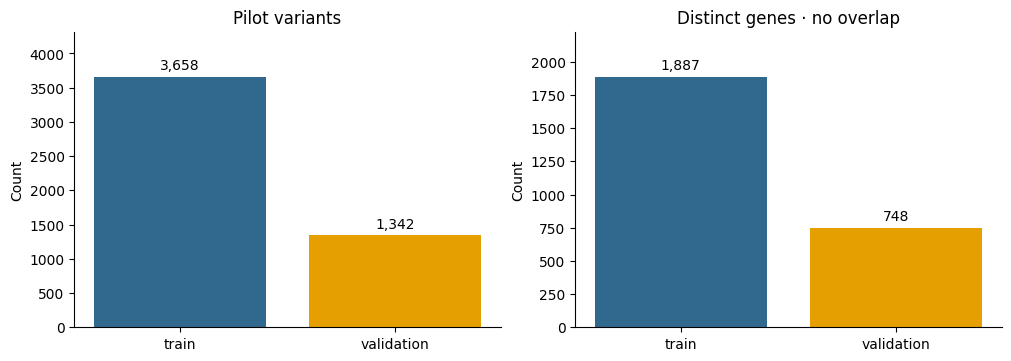

Whole groups are assigned by a fixed hash. Different group sizes make the proportions approximate.


,variants,components,genes,percent,purpose,vcf
split,,,,,,
train,3658,1601,1887,73.16,Fit scaling and classifiers,clinvar-train-pilot.vcf
validation,1342,613,748,26.84,Choose settings and compare models,clinvar-test-pilot.vcf


,stage,retained,removed
0,All records,4469028,0
1,No inconsistent duplicate annotations,4469028,0
2,"Chromosomes 1–22, X, Y",4465847,3181
3,Single A/C/G/T substitution,4157786,308061
4,No germline conflict evidence,3998278,159508
5,Accepted benign/pathogenic label,1486095,2512183
6,At least 2 review stars,346039,1140056
7,At least one usable gene ID,346038,1
8,Collapse consistent duplicate keys,346038,0
9,Exact MC SO:0001583 missense annotation,65270,280768


,variant_key,gene_ids,start,end,component,split
0,GRCh38:2:178574019:G:A,7273|100506866,178573506,178574530,GRCh38:2:178525940:A:G,validation
1,GRCh38:17:43099814:G:A,672,43099301,43100325,GRCh38:17:43039471:G:A,train
2,GRCh38:17:63972170:T:G,6329,63971657,63972681,GRCh38:17:63917337:C:T,validation
3,GRCh38:1:216327619:G:C,7399,216327106,216328130,GRCh38:1:215625538:C:A,train
4,GRCh38:6:87589923:T:C,57038,87589410,87590434,GRCh38:6:87514446:T:C,train
5,GRCh38:3:36993657:A:G,4292,36993144,36994168,GRCh38:3:36988684:C:A,train
6,GRCh38:21:46254837:G:A,8888,46254324,46255348,GRCh38:21:46235113:A:C,train
7,GRCh38:12:102855313:C:G,5053,102854800,102855824,GRCh38:12:102838988:C:T,train
8,GRCh38:3:37047640:A:C,4292,37047127,37048151,GRCh38:3:36988684:C:A,train
9,GRCh38:7:93105875:G:A,54809,93105362,93106386,GRCh38:7:93101355:T:C,train


In [4]:
q1.show_splits(pilot)

[Pilot training VCF](../data/clinvar-train-pilot.vcf) · [Pilot validation VCF](../data/clinvar-test-pilot.vcf)

These files contain the **5,000-variant missense pilot**: **3,658 training** and **1,342 validation variants**. They fix membership for subsequent experiments. Clinical annotations supply eligibility and labels; predictor inputs contain only DNA.

[Pilot manifest](results/q1/split_manifest.csv) · [Full-cohort groups](results/q1/full_cohort_groups.csv.gz) · [Split protocol](results/q1/protocol.json) · [Filter counts](results/q1/filter_counts.csv)

The [earlier broad-SNV experiment](results/archive/broad_snv_before_missense/) preserves its VCFs, manifests, notebooks and Q2 results. Checks cover missense eligibility, preserved assignments, recorded relationships and exact DNA contexts. Homology, shared patients and pretraining overlap remain unresolved. [Q2](Q2-evo2-classifier.ipynb) consumes the new frozen inputs.

## Conclusion

The missense pilot contains **3,658 training** and **1,342 validation variants**, with no shared genes between partitions. Grouping across the broader cohort preserves earlier assignments and relationships before missense sampling. The two VCFs fix this dataset for subsequent experiments; validation supports development, with no independent final test estimate.